In [2]:
import pandas as pd
#from sklearn import 
import os
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import geodatasets
import pydeck as pdk
import streamlit as st

<b>First</b> I want to bring in my dataset to start playing with the data

In [3]:
df = pd.read_csv('data-2026-03.csv', names=['siteid', 'direction', 'type', 'start', 'end', 'count'])

In [4]:
sites = pd.read_csv('sites.csv', names=['siteid', 'site_nr', 'longitude', 'latitude', 'name', 'region', 'direction_number', 'district', 'municipality', 'interval', 'date'])

In [5]:
df.head(10)

,siteid,direction,type,start,end,count
0,1,IN,FIETSERS,2026-03-01 00:00:00.0,2026-03-01 00:15:00.0,0.0
1,1,IN,FIETSERS,2026-03-01 00:15:00.0,2026-03-01 00:30:00.0,0.0
2,1,IN,FIETSERS,2026-03-01 00:30:00.0,2026-03-01 00:45:00.0,0.0
3,1,IN,FIETSERS,2026-03-01 00:45:00.0,2026-03-01 01:00:00.0,0.0
4,1,IN,FIETSERS,2026-03-01 01:00:00.0,2026-03-01 01:15:00.0,1.0
5,1,IN,FIETSERS,2026-03-01 01:15:00.0,2026-03-01 01:30:00.0,0.0
6,1,IN,FIETSERS,2026-03-01 01:30:00.0,2026-03-01 01:45:00.0,1.0
7,1,IN,FIETSERS,2026-03-01 01:45:00.0,2026-03-01 02:00:00.0,0.0
8,1,IN,FIETSERS,2026-03-01 02:00:00.0,2026-03-01 02:15:00.0,0.0
9,1,IN,FIETSERS,2026-03-01 02:15:00.0,2026-03-01 02:30:00.0,0.0


Will want to group sites into a smaller classification so they can be clustered. Maybe group by hour by splitting the start and end times into the hours?

In [6]:
#break the start and end into its component parts
#takes about 4 mins 21 secs to run
df['start_date'] = 'NULL'
df['start_time'] = 0
df['end_date'] = 'NULL'
df['end_time'] = 0




for index, val in df.iterrows():
    df.loc[index, 'start_date'] = df.loc[index, 'start'][:10]
    df.loc[index, 'start_date'] = df.loc[index, 'start_date'][:10]
    
    df.loc[index, 'start_time'] = df.loc[index, 'start'][11:]
    df.loc[index, 'start_time'] = df.loc[index, 'start_time'][:]

    df.loc[index, 'end_date'] = df.loc[index, 'end'][:10]
    df.loc[index, 'end_date'] = df.loc[index, 'end_date'][:10]

    df.loc[index, 'end_time'] = df.loc[index, 'end'][11:]
    df.loc[index, 'end_time'] = df.loc[index, 'end_time'][:]





/var/folders/2v/fznvvjm17tsbhvss80_3zmc00000gn/T/ipykernel_5593/2812288398.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '00:00:00.0' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[index, 'start_time'] = df.loc[index, 'start'][11:]
/var/folders/2v/fznvvjm17tsbhvss80_3zmc00000gn/T/ipykernel_5593/2812288398.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '00:15:00.0' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[index, 'end_time'] = df.loc[index, 'end'][11:]


In [7]:
print(df.loc[index, 'end'][11:])
df.head(10)

05:00:00.0


,siteid,direction,type,start,end,count,start_date,start_time,end_date,end_time
0,1,IN,FIETSERS,2026-03-01 00:00:00.0,2026-03-01 00:15:00.0,0.0,2026-03-01,00:00:00.0,2026-03-01,00:15:00.0
1,1,IN,FIETSERS,2026-03-01 00:15:00.0,2026-03-01 00:30:00.0,0.0,2026-03-01,00:15:00.0,2026-03-01,00:30:00.0
2,1,IN,FIETSERS,2026-03-01 00:30:00.0,2026-03-01 00:45:00.0,0.0,2026-03-01,00:30:00.0,2026-03-01,00:45:00.0
3,1,IN,FIETSERS,2026-03-01 00:45:00.0,2026-03-01 01:00:00.0,0.0,2026-03-01,00:45:00.0,2026-03-01,01:00:00.0
4,1,IN,FIETSERS,2026-03-01 01:00:00.0,2026-03-01 01:15:00.0,1.0,2026-03-01,01:00:00.0,2026-03-01,01:15:00.0
5,1,IN,FIETSERS,2026-03-01 01:15:00.0,2026-03-01 01:30:00.0,0.0,2026-03-01,01:15:00.0,2026-03-01,01:30:00.0
6,1,IN,FIETSERS,2026-03-01 01:30:00.0,2026-03-01 01:45:00.0,1.0,2026-03-01,01:30:00.0,2026-03-01,01:45:00.0
7,1,IN,FIETSERS,2026-03-01 01:45:00.0,2026-03-01 02:00:00.0,0.0,2026-03-01,01:45:00.0,2026-03-01,02:00:00.0
8,1,IN,FIETSERS,2026-03-01 02:00:00.0,2026-03-01 02:15:00.0,0.0,2026-03-01,02:00:00.0,2026-03-01,02:15:00.0
9,1,IN,FIETSERS,2026-03-01 02:15:00.0,2026-03-01 02:30:00.0,0.0,2026-03-01,02:15:00.0,2026-03-01,02:30:00.0


Next I want to add some features to better map the space I can work with.

The list of these is below:
1. Is it the weekend? 1 if yes else 0
2. Sum per hour and create a new column called hour with an integer representing the hour
3. Maybe a month specific qualifier? Like is_summer or is_winter?
4. TBD once I continue working I can try and implement something new
5. Direction, 1 in IN 0 else

In [8]:
for index, val in df.iterrows():
    df.loc[index, 'hour'] = pd.to_numeric(df.loc[index, 'start_time'][:2])

In [9]:
#this works
df['hour_count'] = df.groupby(['siteid', 'start_date', 'hour', 'direction'])['count'].cumsum()

In [10]:
df[['siteid', 'start_time', 'hour', 'count', 'hour_count']].head(20)

,siteid,start_time,hour,count,hour_count
0,1,00:00:00.0,0.0,0.0,0.0
1,1,00:15:00.0,0.0,0.0,0.0
2,1,00:30:00.0,0.0,0.0,0.0
3,1,00:45:00.0,0.0,0.0,0.0
4,1,01:00:00.0,1.0,1.0,1.0
5,1,01:15:00.0,1.0,0.0,1.0
6,1,01:30:00.0,1.0,1.0,2.0
7,1,01:45:00.0,1.0,0.0,2.0
8,1,02:00:00.0,2.0,0.0,0.0
9,1,02:15:00.0,2.0,0.0,0.0


In [11]:
for index, val in df.iterrows():
    insert_val = 0
    if df.loc[index, 'direction'] == 'IN':
        insert_val = 1
    df.loc[index, 'direction_binary'] = insert_val

In [12]:
for index, val in df.iterrows():
    insert_val = 0
    if df.loc[index, 'start_date'] == '2026-03-01':
        insert_val = 1
    elif df.loc[index, 'start_date'] == '2026-03-07' or df.loc[index, 'start_date'] == '2026-03-08':
        insert_val = 1
    elif df.loc[index, 'start_date'] == '2026-03-14' or df.loc[index, 'start_date'] == '2026-03-15':
        insert_val = 1
    elif df.loc[index, 'start_date'] == '2026-03-21':
        insert_val = 1
    df.loc[index, 'is_weekend'] = insert_val

In [13]:
for index, val in df.iterrows():
    df.loc[index, 'day'] = pd.to_numeric(df.loc[index, 'start_date'][-2:])

KeyboardInterrupt: 

In [14]:
df

,siteid,direction,type,start,end,count,start_date,start_time,end_date,end_time,hour,hour_count,direction_binary,is_weekend,day
0,1,IN,FIETSERS,2026-03-01 00:00:00.0,2026-03-01 00:15:00.0,0.0,2026-03-01,00:00:00.0,2026-03-01,00:15:00.0,0.0,0.0,1.0,1.0,1.0
1,1,IN,FIETSERS,2026-03-01 00:15:00.0,2026-03-01 00:30:00.0,0.0,2026-03-01,00:15:00.0,2026-03-01,00:30:00.0,0.0,0.0,1.0,1.0,1.0
2,1,IN,FIETSERS,2026-03-01 00:30:00.0,2026-03-01 00:45:00.0,0.0,2026-03-01,00:30:00.0,2026-03-01,00:45:00.0,0.0,0.0,1.0,1.0,1.0
3,1,IN,FIETSERS,2026-03-01 00:45:00.0,2026-03-01 01:00:00.0,0.0,2026-03-01,00:45:00.0,2026-03-01,01:00:00.0,0.0,0.0,1.0,1.0,1.0
4,1,IN,FIETSERS,2026-03-01 01:00:00.0,2026-03-01 01:15:00.0,1.0,2026-03-01,01:00:00.0,2026-03-01,01:15:00.0,1.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
573069,152,OUT,FIETSERS,2026-03-21 03:45:00.0,2026-03-21 04:00:00.0,0.0,2026-03-21,03:45:00.0,2026-03-21,04:00:00.0,3.0,0.0,0.0,1.0,NaN
573070,152,OUT,FIETSERS,2026-03-21 04:00:00.0,2026-03-21 04:15:00.0,0.0,2026-03-21,04:00:00.0,2026-03-21,04:15:00.0,4.0,0.0,0.0,1.0,NaN
573071,152,OUT,FIETSERS,2026-03-21 04:15:00.0,2026-03-21 04:30:00.0,0.0,2026-03-21,04:15:00.0,2026-03-21,04:30:00.0,4.0,0.0,0.0,1.0,NaN
573072,152,OUT,FIETSERS,2026-03-21 04:30:00.0,2026-03-21 04:45:00.0,0.0,2026-03-21,04:30:00.0,2026-03-21,04:45:00.0,4.0,0.0,0.0,1.0,NaN


In [15]:
df1 = df[['siteid', 'hour', 'hour_count', 'is_weekend', 'day', 'direction_binary']]

In [16]:
#df1[df1.isna()]
# Source - https://stackoverflow.com/a/37755016
# Posted by michael_j_ward
# Retrieved 2026-05-20, License - CC BY-SA 3.0

#np.argwhere(np.isnan(df1))


df1.loc[:, ['hour_count']] = df1.loc[:, ['hour_count']].fillna(0)
df1.iloc[256754, 2]

#df1

np.float64(0.0)

In [17]:
df1_crazy = df1.copy()


df1_crazy.replace(0, 10000)

,siteid,hour,hour_count,is_weekend,day,direction_binary
0,1,10000.0,10000.0,1.0,1.0,1.0
1,1,10000.0,10000.0,1.0,1.0,1.0
2,1,10000.0,10000.0,1.0,1.0,1.0
3,1,10000.0,10000.0,1.0,1.0,1.0
4,1,1.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...
573069,152,3.0,10000.0,1.0,NaN,10000.0
573070,152,4.0,10000.0,1.0,NaN,10000.0
573071,152,4.0,10000.0,1.0,NaN,10000.0
573072,152,4.0,10000.0,1.0,NaN,10000.0


In [18]:
#need to do some group bys to try and get better data
#Min count, min count hour, max count, max count hour, min count direction, max count direction, siteid

temp_df1 = df1.groupby('siteid')['hour_count'].idxmin()
temp_df2 = df1.groupby('siteid')['hour_count'].idxmin()
temp_df3 = df1.groupby('siteid')['hour_count'].idxmin()

temp_df4 = df1.groupby('siteid')['hour_count'].idxmax()
temp_df5 = df1.groupby('siteid')['hour_count'].idxmax()
temp_df6 = df1.groupby('siteid')['hour_count'].idxmax()

temp_df7 = df1.groupby('siteid')['hour_count'].mean()

temp_df_dict = {'min_count': temp_df1,
                'min_count_hour': temp_df2,
                'max_count': temp_df3,
                'max_count_hour': temp_df4,
                'min_count_direction': temp_df5,
                'max_count_direction': temp_df6}


#df1

In [19]:
temp_df1[-10:]

siteid
140    533000
143    536886
145    540908
146    544950
147    548994
148    553034
149    557074
150    561114
151    565154
152    569194
Name: hour_count, dtype: int64

In [20]:
pd.to_numeric(df1[df1['siteid']==2].groupby('siteid')['hour_count'].mean())

siteid
2    14.259928
Name: hour_count, dtype: float64

In [21]:
df_cluster = pd.DataFrame()
indx_count = 0
indx_count2 = 0

for indx in temp_df4:
    df_cluster.loc[indx_count, 'siteid'] = temp_df4.index[indx_count]
    df_cluster.loc[indx_count, 'max_hour_count'] = df1.loc[indx, 'hour_count']
    df_cluster.loc[indx_count, 'max_hour'] = df1.loc[indx, 'hour']
    df_cluster.loc[indx_count, 'max_direction'] = df1.loc[indx, 'direction_binary']
    indx_count += 1
    
#include averages
for index in temp_df7:
    df_cluster.loc[indx_count2, 'average_hour_count'] = index
    indx_count2 += 1



In [22]:
df_cluster[-10:]

,siteid,max_hour_count,max_hour,max_direction,average_hour_count
135,140.0,236.0,15.0,0.0,30.634605
136,143.0,575.0,8.0,1.0,67.161466
137,145.0,0.0,0.0,1.0,0.000000
138,146.0,0.0,0.0,1.0,0.000000
139,147.0,41.0,7.0,1.0,2.453713
140,148.0,88.0,17.0,1.0,6.185149
141,149.0,48.0,8.0,1.0,4.845050
142,150.0,42.0,15.0,0.0,2.061386
143,151.0,30.0,8.0,1.0,2.601733
144,152.0,66.0,12.0,0.0,6.580155


In [23]:
df_cluster

#average count per hour as columns in the dataset

,siteid,max_hour_count,max_hour,max_direction,average_hour_count
0,1.0,64.0,10.0,1.0,5.727577
1,2.0,238.0,8.0,1.0,14.259928
2,3.0,203.0,16.0,0.0,12.619588
3,4.0,60.0,11.0,0.0,3.116435
4,5.0,57.0,16.0,0.0,2.935494
...,...,...,...,...,...
140,148.0,88.0,17.0,1.0,6.185149
141,149.0,48.0,8.0,1.0,4.845050
142,150.0,42.0,15.0,0.0,2.061386
143,151.0,30.0,8.0,1.0,2.601733


In [24]:
kmeans = KMeans(n_clusters=3, random_state=0, n_init='auto').fit(df_cluster)

In [25]:
df2 = df_cluster.copy()

In [26]:
df2['cluster'] = kmeans.labels_

In [40]:

df_testing_now = df.groupby(['siteid', 'hour'])['hour_count'].mean()

indz = 0
num = 0
for val in df_testing_now:
    df2.loc[indz, str(num)] = val
    if num < 23:
        num += 1
    else:
        num = 0
        indz += 1

#for val in 

In [41]:
df2[-10:]

,siteid,max_hour_count,max_hour,max_direction,average_hour_count,cluster,0,1,2,3,...,14,15,16,17,18,19,20,21,22,23
135,140.0,236.0,15.0,0.0,30.634605,2,3.898810,2.541667,1.815476,1.196429,...,46.687500,74.075000,72.831250,61.600000,41.537500,26.868750,16.256250,14.437500,11.912500,5.562500
136,143.0,575.0,8.0,1.0,67.161466,1,12.063218,8.232143,4.863095,3.720238,...,95.892857,116.910714,195.220238,159.202381,102.208333,65.589286,45.119048,36.678571,29.809524,18.488095
137,145.0,0.0,0.0,1.0,0.000000,0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
138,146.0,0.0,0.0,1.0,0.000000,0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
139,147.0,41.0,7.0,1.0,2.453713,0,0.380682,0.208333,0.089286,0.065476,...,3.380952,5.107143,6.458333,6.041667,4.684524,2.470238,1.458333,0.702381,0.446429,0.440476
140,148.0,88.0,17.0,1.0,6.185149,0,0.301136,0.125000,0.041667,0.000000,...,9.797619,10.976190,13.095238,19.285714,14.821429,5.345238,1.446429,0.833333,0.738095,0.452381
141,149.0,48.0,8.0,1.0,4.845050,0,0.125000,0.136905,0.041667,0.029762,...,6.696429,9.910714,13.392857,15.517857,10.267857,3.672619,2.095238,0.988095,0.738095,0.244048
142,150.0,42.0,15.0,0.0,2.061386,0,0.153409,0.047619,0.160714,0.000000,...,4.285714,4.255952,4.696429,6.071429,3.982143,1.464286,0.755952,0.375000,0.196429,0.125000
143,151.0,30.0,8.0,1.0,2.601733,0,0.284091,0.196429,0.136905,0.071429,...,3.226190,4.488095,6.369048,7.458333,5.059524,2.404762,1.488095,1.077381,0.857143,0.398810
144,152.0,66.0,12.0,0.0,6.580155,0,0.184524,0.065476,0.095238,0.119048,...,14.850000,16.400000,19.418750,15.937500,8.962500,2.525000,1.212500,1.631250,0.962500,0.456250


In [30]:
df_cluster[-10:]

,siteid,max_hour_count,max_hour,max_direction,average_hour_count,0,1,2,3,4,...,14,15,16,17,18,19,20,21,22,23
135,140.0,236.0,15.0,0.0,30.634605,3.898810,2.541667,1.815476,1.196429,1.325301,...,46.687500,74.075000,72.831250,61.600000,41.537500,26.868750,16.256250,14.437500,11.912500,5.562500
136,143.0,575.0,8.0,1.0,67.161466,12.063218,8.232143,4.863095,3.720238,4.357143,...,95.892857,116.910714,195.220238,159.202381,102.208333,65.589286,45.119048,36.678571,29.809524,18.488095
137,145.0,0.0,0.0,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
138,146.0,0.0,0.0,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
139,147.0,41.0,7.0,1.0,2.453713,0.380682,0.208333,0.089286,0.065476,0.035714,...,3.380952,5.107143,6.458333,6.041667,4.684524,2.470238,1.458333,0.702381,0.446429,0.440476
140,148.0,88.0,17.0,1.0,6.185149,0.301136,0.125000,0.041667,0.000000,0.077381,...,9.797619,10.976190,13.095238,19.285714,14.821429,5.345238,1.446429,0.833333,0.738095,0.452381
141,149.0,48.0,8.0,1.0,4.845050,0.125000,0.136905,0.041667,0.029762,0.184524,...,6.696429,9.910714,13.392857,15.517857,10.267857,3.672619,2.095238,0.988095,0.738095,0.244048
142,150.0,42.0,15.0,0.0,2.061386,0.153409,0.047619,0.160714,0.000000,0.065476,...,4.285714,4.255952,4.696429,6.071429,3.982143,1.464286,0.755952,0.375000,0.196429,0.125000
143,151.0,30.0,8.0,1.0,2.601733,0.284091,0.196429,0.136905,0.071429,0.005952,...,3.226190,4.488095,6.369048,7.458333,5.059524,2.404762,1.488095,1.077381,0.857143,0.398810
144,152.0,66.0,12.0,0.0,6.580155,0.184524,0.065476,0.095238,0.119048,0.482143,...,14.850000,16.400000,19.418750,15.937500,8.962500,2.525000,1.212500,1.631250,0.962500,0.456250


In [31]:
df21 = df[df['day']==19]

In [32]:
df21_test = df21[df21['siteid']==152]

In [33]:
for index, val in df21_test.iterrows():
    print(val)

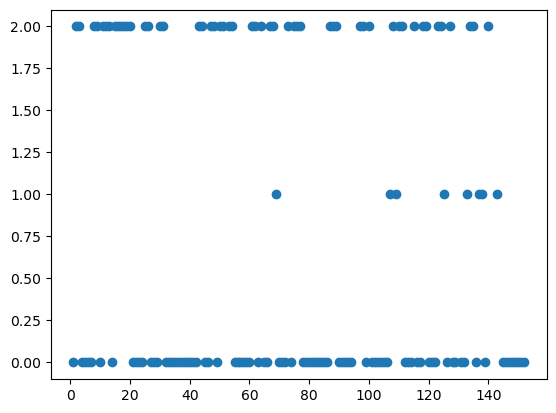

In [34]:
fig, ax = plt.subplots()
ax.scatter(df2['siteid'], df2['cluster'])

#plt.savefig('testing.png', dpi=500)
#df2[['siteid', 'cluster']]

I need a way to group each site so I can then run k-means and get clusters PER SITE not per recorded instance

weights per hour based on count to indicate where the most rides occur

maybe max and min hours or max and min counts? remove direction

Hour with max cyclists per day and then average those

In [ ]:
df2.to_csv('testing.csv', index=False)

In [ ]:
df2.groupby('cluster')['22'].mean()

KeyError: 'cluster'

In [46]:
df_varun = pd.DataFrame()
varun_list = []
for num in range(0, 24):
    a = df2.groupby('cluster')[str(num)].mean()
    for val in a:
        varun_list.append(val)



In [47]:
indz = 0
num = 0
for val in varun_list:
    df_varun.loc[indz, str(num)] = val
    if indz < 2:
        indz += 1
    else:
        indz = 0
        num += 1


#varun_list

In [48]:
df_varun

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
0,0.317534,0.218783,0.177392,0.193805,0.543269,1.475887,2.583298,6.426231,9.093825,3.582554,...,6.791639,7.932946,10.333365,8.489575,4.960780,2.634555,1.799833,1.655445,1.397828,0.554031
1,5.771876,3.749826,2.256313,1.611607,2.011061,6.633185,15.777827,51.090588,110.506176,41.155022,...,53.871205,73.695089,96.724777,90.160751,61.824182,35.641741,24.765885,20.895424,19.688579,11.002195
2,1.143559,0.694650,0.516213,0.450958,0.755590,2.541940,5.274003,16.630038,32.222133,11.213302,...,17.293598,20.959128,28.738613,23.103849,14.215705,7.705476,5.052260,4.286161,4.206120,1.789343


Now I will want to map the clusters to see if these results make some kind of sense

In [45]:
sites[-15:]

,siteid,site_nr,longitude,latitude,name,region,direction_number,district,municipality,interval,date
136,137,300031561,5.341758,50.941161,Hasselt-Kempische brug,Vlaamse Overheid A. Wegen enVerkeer,N0740002,AWV720,Hasselt,15,2023-04-19
137,138,300031574,5.342247,50.940532,Hasselt-Kempische brug,Vlaamse Overheid A. Wegen enVerkeer,N0740001,AWV720,Hasselt,15,2023-04-20
138,139,300031607,5.381980,51.064427,Houthalen-Helchteren,Vlaamse Overheid A. Wegen enVerkeer,N7150002,AWV717,Houthalen-Helchteren,15,2023-04-21
139,140,300031927,5.343862,50.930004,Hasselt ring,Vlaamse Overheid A. Wegen enVerkeer,R0700002,AWV720,Hasselt,15,2023-05-04
140,142,300036881,3.240950,51.226320,TEST Validatie BRUGGE Y2H22022134,Vlaamse Overheid A. Wegen enVerkeer,N3740002,AWV311,Brugge,15,2023-10-24
141,143,100038932,3.262860,50.830660,Eco Display Classic Budastraat,Kortrijk Fietst,NaN,NaN,Kortrijk,15,2023-12-08
142,144,300038692,4.715373,50.875576,test leuven,Vlaamse Overheid A. Wegen enVerkeer,R0230002,AWV213,Leuven,15,2024-01-12
143,145,300052743,4.490876,50.788586,Overijse,Vlaamse Overheid A. Wegen en Verkeer,A0040002,Overijse,District Vilvoorde-gewestwegen,15,2025-05-22
144,146,300052800,4.490282,50.788148,Overijse 2,Vlaamse Overheid A. Wegen en Verkeer,A0040001,Overijse,District Vilvoorde-gewestwegen,15,2025-05-23
145,147,300059948,4.497577,50.779756,Overijse,Vlaamse Overheid A. Wegen en Verkeer,A0040001,Overijse,District Vilvoorde-gewestwegen,0,2025-08-22


In [ ]:
starting_view = pdk.ViewState(latitude= 5, longitude= 50, zoom= 10, max_zoom= 16)

site_locations = pdk.Layer(
    'ScatterplotLayer',
    sites[['longitude', 'latitude']],
    auto_highlight=True,
    get_position=['longitude', 'latitude'],
    get_radius=1000,
    get_fill_color=[100,100,200,0],
    pickable=True
)

design = pdk.Deck(layers= [site_locations], initial_view_state = starting_view)
st.pydeck_chart(design)

2026-05-21 17:42:36.909 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-21 17:42:36.910 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-21 17:42:36.911 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [54]:
site_location_dict = {}

for index, value in sites[['siteid','longitude', 'latitude']].iterrows():
    site_location_dict[value[0]] = [value[1], value[2]]

/var/folders/2v/fznvvjm17tsbhvss80_3zmc00000gn/T/ipykernel_5593/1571555356.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  site_location_dict[value[0]] = [value[1], value[2]]


In [53]:
site_location_dict

NameError: name 'site_location_dict' is not defined

In [ ]:
sites.insert(loc=1, column='cluster_new', value=df2['cluster'])

In [50]:
sites_updated = df2[['siteid', 'cluster']].copy()

sites_updated_export = sites_updated.copy

In [ ]:
sites_updated_export

<bound method NDFrame.copy of      siteid  cluster
0       1.0        0
1       2.0        2
2       3.0        2
3       4.0        0
4       5.0        0
..      ...      ...
140   148.0        0
141   149.0        0
142   150.0        0
143   151.0        0
144   152.0        0

[145 rows x 2 columns]>

In [52]:
site_location_dict[1][0]

NameError: name 'site_location_dict' is not defined

In [55]:
for index, val in sites_updated.iterrows():
    if val.siteid in site_location_dict:
        sites_updated.loc[index, 'longitude'] = site_location_dict[val.siteid][0]
        sites_updated.loc[index, 'latitude'] = site_location_dict[val.siteid][1]

In [56]:
sites_updated

,siteid,cluster,longitude,latitude
0,1.0,0,4.456122,50.916183
1,2.0,2,4.471690,51.275120
2,3.0,2,4.472220,51.275030
3,4.0,0,5.190110,51.160230
4,5.0,0,5.190030,51.160180
...,...,...,...,...
140,148.0,0,4.444710,50.766995
141,149.0,0,4.433566,50.882979
142,150.0,0,4.561363,50.868753
143,151.0,0,4.685484,50.869026


In [60]:
for index, val in sites_updated.iterrows():
    if val.cluster == 0:
        sites_updated.loc[index, 'color1'] = 20
        sites_updated.loc[index, 'color2'] = 20
        sites_updated.loc[index, 'color3'] = 255
    elif val.cluster == 1:
        sites_updated.loc[index, 'color1'] = 255
        sites_updated.loc[index, 'color2'] = 20
        sites_updated.loc[index, 'color3'] = 20
    else:
        sites_updated.loc[index, 'color1'] = 20
        sites_updated.loc[index, 'color2'] = 255
        sites_updated.loc[index, 'color3'] = 20

In [61]:
sites_updated.to_csv('sites_cluster.csv', index=False)

In [ ]:
sites[-10:]

,siteid,cluster_new,cluster,site_nr,longitude,latitude,name,region,direction_number,district,municipality,interval,date
141,143,0.0,0.0,100038932,3.262860,50.830660,Eco Display Classic Budastraat,Kortrijk Fietst,NaN,NaN,Kortrijk,15,2023-12-08
142,144,0.0,0.0,300038692,4.715373,50.875576,test leuven,Vlaamse Overheid A. Wegen enVerkeer,R0230002,AWV213,Leuven,15,2024-01-12
143,145,0.0,0.0,300052743,4.490876,50.788586,Overijse,Vlaamse Overheid A. Wegen en Verkeer,A0040002,Overijse,District Vilvoorde-gewestwegen,15,2025-05-22
144,146,0.0,0.0,300052800,4.490282,50.788148,Overijse 2,Vlaamse Overheid A. Wegen en Verkeer,A0040001,Overijse,District Vilvoorde-gewestwegen,15,2025-05-23
145,147,NaN,NaN,300059948,4.497577,50.779756,Overijse,Vlaamse Overheid A. Wegen en Verkeer,A0040001,Overijse,District Vilvoorde-gewestwegen,0,2025-08-22
146,148,NaN,NaN,300060140,4.444710,50.766995,Hoeilaart,Vlaamse Overheid A. Wegen en Verkeer,N2750002,Hoeilaart,District Leuven,0,2025-08-23
147,149,NaN,NaN,300060264,4.433566,50.882979,Machelen,Vlaamse Overheid A. Wegen en Verkeer,NaN,NaN,NaN,0,2025-08-28
148,150,NaN,NaN,300061690,4.561363,50.868753,Bertem,Vlaamse Overheid A. Wegen en Verkeer,A0030002,Kortenberg,District Leuven,15,2025-10-17
149,151,NaN,NaN,300061739,4.685484,50.869026,Leuven,Vlaamse Overheid A. Wegen en Verkeer,N2640002,Leuven,District Leuven,0,2025-10-18
150,152,NaN,NaN,300062103,4.149169,50.968901,Opwijk,Vlaamse Overheid A. Wegen en Verkeer,N0470002,Opwijk,District Vilvoorde-gewestwegen,15,2025-10-31


In [ ]:
pd.unique(df['siteid'])

#NO 52, 95, 96, 130, 141, 142, 144

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  53,
        54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,  66,
        67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,  79,
        80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,  92,
        93,  94,  97,  98,  99, 100, 101, 102, 103, 104, 105, 106, 107,
       108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120,
       121, 122, 123, 124, 125, 126, 127, 128, 129, 131, 132, 133, 134,
       135, 136, 137, 138, 139, 140, 143, 145, 146, 147, 148, 149, 150,
       151, 152])